## How are in-demand skills trending for Data Analysts?


#### Methology

###### 1.Aggregate skill counts monthly 
###### 2. Re-analyze based on percentage of total jobs 
###### 3. Plot the monthly skill demnand 

In [1]:
import ast 
import seaborn as sns 
import pandas as pd 
import matplotlib.pyplot as plt 

data = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Documents\Projects\Luke Barousse Projects\Python Course  Data Analysis\data_jobs.csv")
df=data
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)


In [2]:
df_DA_US = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US['job_posted_month_no'] = df_DA_US['job_posted_date'].dt.month
df_DA_US_explode=df_DA_US.explode('job_skills')

In [18]:
df_DA_US_pivot=df_DA_US_explode.pivot_table(index='job_posted_month_no',columns='job_skills',aggfunc='size',fill_value=0) 
df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()
df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc["Total"].sort_values(ascending=False).index]
df_DA_US_pivot = df_DA_US_pivot.drop('Total')

In [21]:
DA_totals=df_DA_US.groupby('job_posted_month_no').size()

In [25]:
df_DA_US_percent=df_DA_US_pivot.div(DA_totals/100,axis=0)

In [27]:
df_DA_US_percent=df_DA_US_percent.reset_index()
df_DA_US_percent['job_posted_month']=df_DA_US_percent['job_posted_month_no'].apply(lambda x:pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_US_percent = df_DA_US_percent.set_index('job_posted_month')
df_DA_US_percent = df_DA_US_percent.drop(columns='job_posted_month_no')

In [38]:
df_DA_US_percent.drop(columns='index')

job_skills,sql,excel,tableau,python,power bi,sas,r,word,powerpoint,oracle,...,mariadb,mxnet,next.js,ringcentral,sqlserver,svelte,theano,tidyr,symphony,yarn
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,63.181068,43.148046,35.608145,29.223996,17.941662,21.463952,18.877270,9.025867,9.576225,9.246010,...,0.000000,0.000000,0.000000,0.055036,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,60.434445,42.280838,32.350659,29.402638,23.429015,21.567106,17.610551,10.085337,10.085337,7.602793,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,59.590044,42.752562,33.894583,29.795022,20.131772,22.108346,18.081991,11.054173,9.663250,8.272328,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,60.716898,41.989759,32.991953,30.285296,21.506950,18.434528,17.190929,10.314557,9.948793,8.851500,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,61.077844,42.258340,31.736527,28.742515,21.642429,18.306245,18.391788,7.784431,10.265184,8.126604,...,0.085543,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,61.454849,40.802676,32.775920,32.525084,22.826087,16.722408,20.568562,10.618729,9.782609,7.859532,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,58.117890,45.708376,31.127198,30.093071,20.475698,18.200620,19.441572,10.444674,10.134436,6.618407,...,0.000000,0.000000,0.103413,0.000000,0.103413,0.000000,0.000000,0.000000,0.000000,0.103413
Aug,55.681016,45.306987,34.086097,32.745236,20.395201,19.336627,22.653493,7.974594,9.456598,7.268878,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,56.826138,38.389732,32.205368,29.988331,21.703617,16.802800,18.903151,7.701284,6.184364,7.584597,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.116686,0.000000


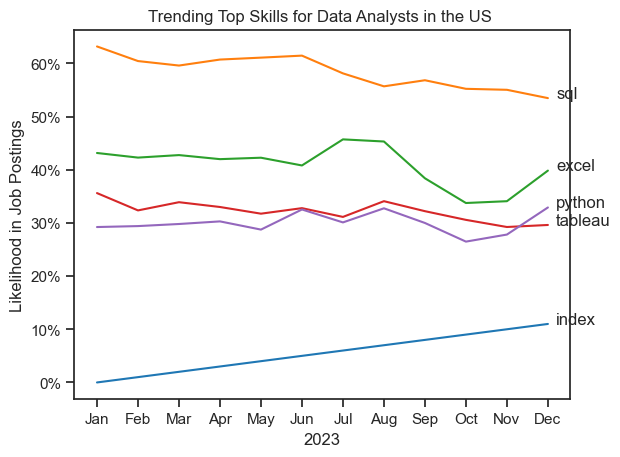

In [40]:
df_plot=df_DA_US_percent.iloc[:,:5]
sns.lineplot(data=df_plot,dashes=False ,palette='tab10')
sns.set_theme(style='ticks')
plt.title('Trending Top Skills for Data Analysts in the US ')
plt.ylabel('Likelihood in Job Postings')
plt.xlabel('2023')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter 
ax=plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
for i in range(5):
    plt.text(11.2,df_plot.iloc[-1,i],df_plot.columns[i])


In [44]:
df_DA_US_percent.iloc[:,:6]


job_skills,index,sql,excel,tableau,python,power bi
job_posted_month,,,,,,
Jan,0,63.181068,43.148046,35.608145,29.223996,17.941662
Feb,1,60.434445,42.280838,32.350659,29.402638,23.429015
Mar,2,59.590044,42.752562,33.894583,29.795022,20.131772
Apr,3,60.716898,41.989759,32.991953,30.285296,21.506950
May,4,61.077844,42.258340,31.736527,28.742515,21.642429
Jun,5,61.454849,40.802676,32.775920,32.525084,22.826087
Jul,6,58.117890,45.708376,31.127198,30.093071,20.475698
Aug,7,55.681016,45.306987,34.086097,32.745236,20.395201
Sep,8,56.826138,38.389732,32.205368,29.988331,21.703617
